In [53]:
import pandas as pd

In [54]:
df = pd.read_csv('data.csv', encoding='latin1')
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_12644\3839603254.py:1: DtypeWarning: Columns (0: stn_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', encoding='latin1')


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,01-02-1990
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,01-02-1990
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,01-02-1990
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,01-03-1990
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,01-03-1990


In [55]:
df.columns

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='str')

In [56]:
df.dtypes

stn_code                        object
sampling_date                      str
state                              str
location                           str
agency                             str
type                               str
so2                            float64
no2                            float64
rspm                           float64
spm                            float64
location_monitoring_station        str
pm2_5                          float64
date                               str
dtype: object

In [57]:
df.isna().sum()

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149481
type                             5393
so2                             34646
no2                             16233
rspm                            40222
spm                            237387
location_monitoring_station     27491
pm2_5                          426428
date                                7
dtype: int64

In [58]:
df=df.drop(['stn_code','agency','location_monitoring_station','pm2_5'],axis=1)

In [59]:
#remove the NaN Records in location
df = df.dropna(subset=['location'])

In [60]:
#fill the emty data by mode(for object data) and mean(for int data)
df['type']=df['type'].fillna(df['type'].mode()[0])
df['so2']=df['so2'].fillna(df['so2'].mean())
df['no2']=df['no2'].fillna(df['no2'].mean())
df['rspm']=df['rspm'].fillna(df['rspm'].mean())
df['spm'] = df['spm'].fillna(df['spm'].mean())

In [61]:
df.isna().sum()

sampling_date    0
state            0
location         0
type             0
so2              0
no2              0
rspm             0
spm              0
date             4
dtype: int64

In [62]:
#calculate the AQI using s02,no2,rspm,spm column 

def calculate_aqi(row):
    def sub_index(value, breakpoints):
        for (bp_lo, bp_hi, aqi_lo, aqi_hi) in breakpoints:
            if bp_lo <= value <= bp_hi:
                return ((aqi_hi - aqi_lo) / (bp_hi - bp_lo)) * (value - bp_lo) + aqi_lo
        return None

    so2_bp  = [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,2620,401,500)]
    no2_bp  = [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,800,401,500)]
    rspm_bp = [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,350,401,500)]
    spm_bp  = [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,450,301,400),(451,600,401,500)]

    indexes = []
    for val, bp in [(row['so2'], so2_bp), (row['no2'], no2_bp),
                    (row['rspm'], rspm_bp), (row['spm'], spm_bp)]:
        si = sub_index(val, bp)
        if si: indexes.append(si)

    return round(max(indexes)) if indexes else None

df['aqi'] = df.apply(calculate_aqi, axis=1)
print(df['aqi'].describe())

count    434979.000000
mean        240.417685
std          95.321063
min           2.000000
25%         181.000000
50%         225.000000
75%         314.000000
max         500.000000
Name: aqi, dtype: float64


In [63]:
#give this AQI value to the label like aui<50 good

def aqi_label(aqi):
    if aqi <= 50:     return 'Good'
    elif aqi <= 100:  return 'Satisfactory'
    elif aqi <= 200:  return 'Moderate'
    elif aqi <= 300:  return 'Poor'
    elif aqi <= 400:  return 'Very Poor'
    else:             return 'Severe'

df['aqi_status'] = df['aqi'].apply(aqi_label)
print(df['aqi_status'].value_counts())

aqi_status
Moderate        168267
Very Poor       111925
Poor            101114
Satisfactory     25602
Severe           24328
Good              4503
Name: count, dtype: int64


In [64]:
df.head()

,sampling_date,state,location,type,so2,no2,rspm,spm,date,aqi,aqi_status
0,February - M021990,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,108.832784,220.78348,01-02-1990,262.0,Poor
1,February - M021990,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,108.832784,220.78348,01-02-1990,262.0,Poor
2,February - M021990,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,108.832784,220.78348,01-02-1990,262.0,Poor
3,March - M031990,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,108.832784,220.78348,01-03-1990,262.0,Poor
4,March - M031990,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,108.832784,220.78348,01-03-1990,262.0,Poor


In [66]:
#change the formate for date and add season name
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Check if any dates failed to parse
if df['date'].isna().any():
    print(f"Warning: {df['date'].isna().sum()} dates could not be parsed and were set to NaT")

df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:       return 'Winter'
    elif month in [3, 4, 5]:      return 'Summer'
    elif month in [6, 7, 8, 9]:   return 'Monsoon'
    else:                         return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

# If you still have NaT values, you might want to drop them
df = df.dropna(subset=['date'])

In [67]:
#remove the sample_date column
df.drop(columns=[ 'sampling_date'], inplace=True)

In [68]:
df.head()

,state,location,type,so2,no2,rspm,spm,date,aqi,aqi_status,year,month,quarter,season
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,108.832784,220.78348,1990-02-01,262.0,Poor,1990.0,2.0,1.0,Winter
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,108.832784,220.78348,1990-02-01,262.0,Poor,1990.0,2.0,1.0,Winter
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,108.832784,220.78348,1990-02-01,262.0,Poor,1990.0,2.0,1.0,Winter
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,108.832784,220.78348,1990-03-01,262.0,Poor,1990.0,3.0,1.0,Summer
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,108.832784,220.78348,1990-03-01,262.0,Poor,1990.0,3.0,1.0,Summer


In [69]:
#convert string data to integer data
from sklearn.preprocessing import LabelEncoder
#for status_order
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
status_map = {s: i for i, s in enumerate(status_order)}
df['aqi_status'] = df['aqi_status'].map(status_map)
#for season
season_map = {'Winter': 0, 'Summer': 1, 'Monsoon': 2, 'Post-Monsoon': 3}
df['season'] = df['season'].map(season_map)

#for state, location, type
le = LabelEncoder()

df['state']    = le.fit_transform(df['state'])
df['location'] = le.fit_transform(df['location'])
df['type']     = le.fit_transform(df['type'])

In [70]:
#remove date coulmn because we have season
df.drop(columns=['date'], inplace=True)

In [71]:
#devide the data into train and test
from sklearn.model_selection import train_test_split
x=df.drop(['aqi','aqi_status'],axis=1)
#y= aqi_status because we want to do classification
y=df['aqi_status'] 
#using stratify=y devide the data same means if there is 0 in train data for 50 time and in test 0  will be 8 to 9.
#if we dont use stratify=y then maybe devide the data like in train 50 time 0 and in test only 1 time 0
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)


X_train: (348588, 11)
X_test: (87147, 11)


In [72]:
#prepare the evaluate function
from sklearn.metrics import classification_report,confusion_matrix,cohen_kappa_score,accuracy_score
def evaluate_model(y_test,y_pred):
    cm=confusion_matrix(y_test,y_pred)
    print('Confusion matrix:',cm)
    ac=accuracy_score(y_test,y_pred)
    print('Accuracy: ',ac)
    cr=classification_report(y_test,y_pred)
    print('Classification report',cr)
    print('Error rate: ',1-ac)
    kp=cohen_kappa_score(y_test,y_pred)
    print('Kappa score: ',kp)

In [73]:
df.drop(columns=['quarter'], inplace=True)
df.dropna(subset=['year', 'month'], inplace=True)

In [74]:
#find the NaN value 
print(x_train.isna().sum()[x_train.isna().sum() > 0])

Series([], dtype: int64)


In [75]:
#remove the NaN value and convert with mean of that coulmn data
x_train.fillna(x_train.mean(), inplace=True)
x_test.fillna(x_test.mean(), inplace=True)

,state,location,type,so2,no2,rspm,spm,year,month,quarter,season
265494,21,148,6,2.000000,5.0,43.000000,220.78348,2014.0,4.0,2.0,1
242279,18,197,1,13.000000,40.0,160.000000,220.78348,2013.0,5.0,2.0,1
86138,10,2,2,14.400000,27.3,140.000000,315.00000,2006.0,6.0,2.0,2
71282,8,72,5,10.829414,37.3,159.000000,412.00000,2009.0,10.0,4.0,3
51501,4,49,5,10.829414,19.0,172.000000,348.00000,2008.0,6.0,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...
21563,0,54,6,5.000000,11.0,70.000000,220.78348,2014.0,9.0,3.0,2
46556,3,76,6,14.000000,8.2,108.832784,127.00000,2000.0,7.0,3.0,2
116753,12,131,1,3.000000,16.0,277.000000,220.78348,2011.0,11.0,4.0,3
277983,23,230,5,2.500000,21.8,63.000000,112.00000,2009.0,10.0,4.0,3


In [76]:
#for Naive Bayes
from sklearn.naive_bayes import GaussianNB
gb=GaussianNB()
gb.fit(x_train,y_train)
y_pred_nb=gb.predict(x_test)
evaluate_model(y_test,y_pred_nb)

Confusion matrix: [[   27   799     0     1     0    74]
 [    4  4708   304     3     4    97]
 [   23  2437 29233   956   306   698]
 [   42    67  8273 11104   469   267]
 [   22    26  4731  1633 15207   766]
 [   80   151     0   248  1062  3325]]
Accuracy:  0.7298472695560375
Classification report               precision    recall  f1-score   support

           0       0.14      0.03      0.05       901
           1       0.57      0.92      0.71      5120
           2       0.69      0.87      0.77     33653
           3       0.80      0.55      0.65     20222
           4       0.89      0.68      0.77     22385
           5       0.64      0.68      0.66      4866

    accuracy                           0.73     87147
   macro avg       0.62      0.62      0.60     87147
weighted avg       0.75      0.73      0.72     87147

Error rate:  0.2701527304439625
Kappa score:  0.6222807211585114


In [77]:
# for Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,        # limit tree depth
    min_samples_leaf=5,  # min samples per leaf
    random_state=42,
    class_weight='balanced'
)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
evaluate_model(y_test,y_pred_rf)

Confusion matrix: [[  893     4     1     0     1     2]
 [    6  5112     0     0     0     2]
 [    6    30 33264     5    10   338]
 [    0     0     7 20146     1    68]
 [    0     0     2     4 22236   143]
 [    0     0     0     0     0  4866]]
Accuracy:  0.9927708354848704
Classification report               precision    recall  f1-score   support

           0       0.99      0.99      0.99       901
           1       0.99      1.00      1.00      5120
           2       1.00      0.99      0.99     33653
           3       1.00      1.00      1.00     20222
           4       1.00      0.99      1.00     22385
           5       0.90      1.00      0.95      4866

    accuracy                           0.99     87147
   macro avg       0.98      0.99      0.99     87147
weighted avg       0.99      0.99      0.99     87147

Error rate:  0.00722916451512956
Kappa score:  0.9900461247143464


In [78]:
#for knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train.sample(20000, random_state=42), y_train.sample(20000, random_state=42))
y_pred_knn=knn.predict(x_test)
evaluate_model(y_test,y_pred_knn)

Confusion matrix: [[  671   191     5     1     2    31]
 [   93  4815   202     0     0    10]
 [    1   256 32672   661     7    56]
 [    0     0   705 19081   418    18]
 [    1     0     0   754 21432   198]
 [    3     4    19     2   210  4628]]
Accuracy:  0.9558447221361608
Classification report               precision    recall  f1-score   support

           0       0.87      0.74      0.80       901
           1       0.91      0.94      0.93      5120
           2       0.97      0.97      0.97     33653
           3       0.93      0.94      0.94     20222
           4       0.97      0.96      0.96     22385
           5       0.94      0.95      0.94      4866

    accuracy                           0.96     87147
   macro avg       0.93      0.92      0.92     87147
weighted avg       0.96      0.96      0.96     87147

Error rate:  0.044155277863839215
Kappa score:  0.939067728995875


In [79]:
#for Decison Tree
from sklearn import tree
dsc=tree.DecisionTreeClassifier()
dsc.fit(x_train,y_train)
y_pred_dsc=dsc.predict(x_test)
evaluate_model(y_test,y_pred_dsc)

Confusion matrix: [[  896     3     0     0     1     1]
 [    0  5119     1     0     0     0]
 [    0     1 33650     2     0     0]
 [    0     0     0 20222     0     0]
 [    0     0     0     3 22381     1]
 [    0     0     0     0     2  4864]]
Accuracy:  0.999827877035354
Classification report               precision    recall  f1-score   support

           0       1.00      0.99      1.00       901
           1       1.00      1.00      1.00      5120
           2       1.00      1.00      1.00     33653
           3       1.00      1.00      1.00     20222
           4       1.00      1.00      1.00     22385
           5       1.00      1.00      1.00      4866

    accuracy                           1.00     87147
   macro avg       1.00      1.00      1.00     87147
weighted avg       1.00      1.00      1.00     87147

Error rate:  0.000172122964645971
Kappa score:  0.9997623838779707


In [80]:
from sklearn.svm import LinearSVC

svc = LinearSVC(random_state=42, class_weight='balanced', max_iter=1000)
svc.fit(x_train, y_train)
y_pred_svc = svc.predict(x_test)
evaluate_model(y_test, y_pred_svc)

Confusion matrix: [[    0   796     6     0     0    99]
 [    0  4362   682     0     2    74]
 [   58  2891 29793   248   555   108]
 [ 1096  2980 10487  1638  3829   192]
 [  485   187  1285   430 17563  2435]
 [    0   174   204    11  1849  2628]]
Accuracy:  0.6424088035158985
Classification report               precision    recall  f1-score   support

           0       0.00      0.00      0.00       901
           1       0.38      0.85      0.53      5120
           2       0.70      0.89      0.78     33653
           3       0.70      0.08      0.15     20222
           4       0.74      0.78      0.76     22385
           5       0.47      0.54      0.51      4866

    accuracy                           0.64     87147
   macro avg       0.50      0.52      0.45     87147
weighted avg       0.67      0.64      0.59     87147

Error rate:  0.35759119648410154
Kappa score:  0.5061611367985381


In [81]:
from sklearn.metrics import roc_auc_score

# AUC for multiclass
auc_nb  = roc_auc_score(y_test, gb.predict_proba(x_test), multi_class='ovr', average='macro')
auc_knn = roc_auc_score(y_test, knn.predict_proba(x_test), multi_class='ovr', average='macro')
auc_rf  = roc_auc_score(y_test, rf.predict_proba(x_test), multi_class='ovr', average='macro')
auc_dsc = roc_auc_score(y_test, dsc.predict_proba(x_test), multi_class='ovr', average='macro')

print("AUC NB: ", auc_nb)
print("AUC KNN:", auc_knn)
print("AUC RF: ", auc_rf)
print("AUC DT: ", auc_dsc)

AUC NB:  0.9443690635090055
AUC KNN: 0.9927585652387814
AUC RF:  0.9999570676190493
AUC DT:  0.9994469706263542


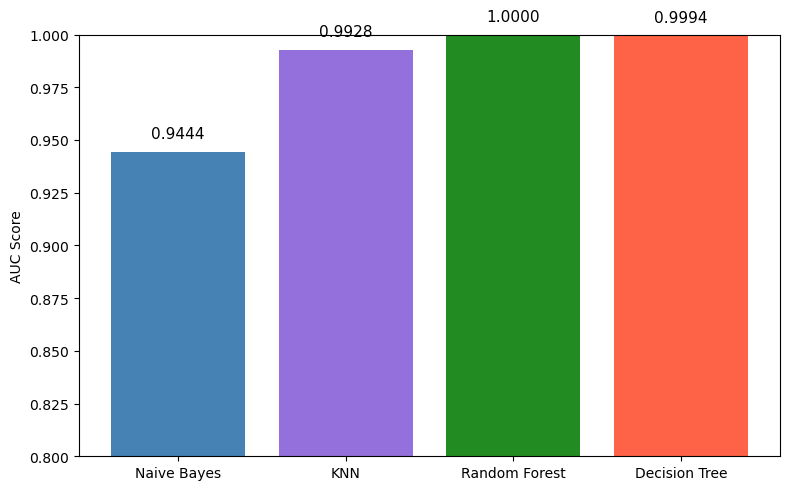

In [82]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Naive Bayes', 'KNN', 'Random Forest', 'Decision Tree']
aucs   = [auc_nb, auc_knn, auc_rf, auc_dsc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, aucs, color=['steelblue', 'mediumpurple', 'forestgreen', 'tomato'])

# add value on top of each bar
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{auc:.4f}', ha='center', va='bottom', fontsize=11)

plt.ylabel('AUC Score')
plt.ylim(0.8, 1.0)  # adjust if needed
plt.tight_layout()
plt.show()

In [83]:
#now save the model
import pickle
pickle.dump(rf, open('aqi_model.pkl', 'wb'))